# PHM 2010 — Chargement & Extraction de Features
### Prédiction de l'état d'usure de fraise (Flank Wear VB)

**Structure attendue du dataset :**
```
dataset_4/
  c1/  c4/  c6/
    c_X_001.csv
    c_X_002.csv
    ...
```
**7 colonnes par fichier :** Force X/Y/Z | Vibration X/Y/Z | Acoustic Emission  
**Dernière colonne = label VB (usure en mm)**

## 0. Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports OK')

✅ Imports OK


## 1. Configuration — adapte le chemin à ton dossier

In [2]:
# ⚠️ MODIFIE CE CHEMIN selon où tu as extrait le dataset
# Ici, le notebook est déjà dans dataset_4, donc on prend le dossier courant
DATASET_PATH = '.'   # ex: '.' si ce notebook est dans dataset_4

# Noms des colonnes (7 signaux + label VB)
COL_NAMES = ['force_x', 'force_y', 'force_z',
             'vib_x',   'vib_y',   'vib_z',
             'ae',      'vb']

# Seuils d'usure classiques (en mm)
VB_SEUILS = {'neuf': 0.0, 'acceptable': 0.2, 'use': 0.3}

print(f'📂 Chemin dataset : {os.path.abspath(DATASET_PATH)}')

📂 Chemin dataset : c:\Users\bourg\OneDrive - DVHE\Bureau\ESILV\stage_furtwangen\dataset_4


## 2. Chargement de tous les CSV

In [3]:
def charger_tous_les_csv(dataset_path, col_names):
    """
    Parcourt tous les sous-dossiers (c1, c4, c6...)
    et charge chaque fichier CSV en DataFrame.
    Retourne une liste de dicts avec les métadonnées.
    """
    records = []
    pattern = os.path.join(dataset_path, '**', '*.csv')
    fichiers = sorted(glob.glob(pattern, recursive=True))
    
    if not fichiers:
        print(f'❌ Aucun CSV trouvé dans {dataset_path}')
        print('   Vérifie ton chemin DATASET_PATH')
        return []
    
    print(f'📄 {len(fichiers)} fichiers CSV trouvés...')
    
    for filepath in fichiers:
        try:
            df = pd.read_csv(filepath, header=None, names=col_names)
            
            # Si la colonne vb n'existe pas mais ae existe, on copie ae -> vb
            if 'ae' in df.columns and 'vb' not in df.columns:
                df['vb'] = df['ae']
            
            # Extraire condition et numéro de passe depuis le nom de fichier
            nom = os.path.basename(filepath).replace('.csv', '')
            parties = nom.split('_')
            condition = f'c{parties[1]}'        # ex: 'c6'
            num_passe = int(parties[2])          # ex: 2
            
            records.append({
                'filepath': filepath,
                'condition': condition,
                'passe': num_passe,
                'data': df
            })
        except Exception as e:
            print(f'  ⚠️ Erreur sur {filepath}: {e}')
    
    print(f'✅ {len(records)} fichiers chargés avec succès')
    return records


raw_data = charger_tous_les_csv(DATASET_PATH, COL_NAMES)

# Aperçu d'un fichier
if raw_data:
    exemple = raw_data[0]
    print(f'\n📋 Exemple : {exemple["condition"]} — passe {exemple["passe"]}')
    print(f'   {len(exemple["data"])} lignes, VB = {exemple["data"]["vb"].iloc[0]:.4f} mm')
    display(exemple['data'].head(3))

📄 1893 fichiers CSV trouvés...
  ⚠️ Erreur sur .\c1\c1_wear.csv: list index out of range
  ⚠️ Erreur sur .\c4\c4_wear.csv: list index out of range
  ⚠️ Erreur sur .\c6\c6_wear.csv: list index out of range
✅ 1890 fichiers chargés avec succès

📋 Exemple : c1 — passe 1
   127399 lignes, VB = nan mm


,force_x,force_y,force_z,vib_x,vib_y,vib_z,ae,vb
0,0.704,-0.387,-1.084,0.018,0.031,0.027,-0.004,NaN
1,0.772,-0.573,-1.153,-0.056,-0.057,-0.058,-0.004,NaN
2,0.828,-0.673,-1.242,0.037,0.019,0.031,-0.004,NaN


## 3. Extraction de features statistiques
Pour chaque fichier (= une passe), on résume les ~200 000 points en **une ligne de features**.

In [4]:
SIGNAL_COLS = ['force_x', 'force_y', 'force_z', 'vib_x', 'vib_y', 'vib_z', 'ae']

def extraire_features(df_signal):
    """
    Extrait des features statistiques pour chaque signal.
    Retourne un dict plat de features.
    """
    features = {}
    
    for col in SIGNAL_COLS:
        sig = df_signal[col].values.astype(float)
        
        # --- Domaine temporel ---
        features[f'{col}_mean']     = np.mean(sig)
        features[f'{col}_std']      = np.std(sig)
        features[f'{col}_rms']      = np.sqrt(np.mean(sig**2))    # Root Mean Square
        features[f'{col}_max']      = np.max(np.abs(sig))
        features[f'{col}_p2p']      = np.ptp(sig)                 # Peak to Peak
        features[f'{col}_skew']     = skew(sig)                   # Asymétrie
        features[f'{col}_kurt']     = kurtosis(sig)               # Aplatissement
        features[f'{col}_crest']    = np.max(np.abs(sig)) / (np.sqrt(np.mean(sig**2)) + 1e-10)  # Crest factor
        features[f'{col}_shape']    = (np.sqrt(np.mean(sig**2))) / (np.mean(np.abs(sig)) + 1e-10)  # Shape factor
        
        # --- Énergie ---
        features[f'{col}_energy']   = np.sum(sig**2)
        
        # --- Percentiles ---
        features[f'{col}_p25']      = np.percentile(sig, 25)
        features[f'{col}_p75']      = np.percentile(sig, 75)
        features[f'{col}_iqr']      = np.percentile(sig, 75) - np.percentile(sig, 25)
    
    return features


def construire_dataframe(raw_data):
    """
    Construit le DataFrame final avec features + labels.
    """
    rows = []
    
    for record in raw_data:
        df = record['data']
        
        # Extraire features des signaux
        feats = extraire_features(df[SIGNAL_COLS])
        
        # Métadonnées
        feats['condition'] = record['condition']
        feats['passe']     = record['passe']
        
        # Label : valeur VB (constante sur tout le fichier)
        feats['ae']        = df['ae'].iloc[0]
        
        # Label catégoriel : état de la fraise
        vb_val = feats['ae']
        if vb_val < 0.1:
            feats['etat'] = 'neuf'
        elif vb_val < 0.2:
            feats['etat'] = 'acceptable'
        elif vb_val < 0.3:
            feats['etat'] = 'use'
        else:
            feats['etat'] = 'tres_use'
        
        rows.append(feats)
    
    return pd.DataFrame(rows)


print('⏳ Extraction des features en cours...')
df_features = construire_dataframe(raw_data)
print(f'✅ DataFrame construit : {df_features.shape[0]} lignes × {df_features.shape[1]} colonnes')
print(f'   Features extraites : {df_features.shape[1] - 4} (hors condition/passe/vb/etat)')
display(df_features.head())

⏳ Extraction des features en cours...


✅ DataFrame construit : 1890 lignes × 95 colonnes
   Features extraites : 91 (hors condition/passe/vb/etat)


,force_x_mean,force_x_std,force_x_rms,force_x_max,force_x_p2p,force_x_skew,force_x_kurt,force_x_crest,force_x_shape,force_x_energy,...,ae_crest,ae_shape,ae_energy,ae_p25,ae_p75,ae_iqr,condition,passe,ae,etat
0,0.400857,0.842468,0.932973,3.744,6.245,0.115205,-0.245189,4.012978,1.251618,1.108930e+05,...,4.483496,1.274877,0.633771,-0.002,0.001,0.003,c1,1,-0.004,neuf
1,1.028151,1.864977,2.129609,8.427,12.646,0.606325,0.022639,3.957065,1.345953,9.854836e+05,...,2.999761,1.054356,359.414850,0.031,0.044,0.013,c1,2,-0.005,neuf
2,1.776092,2.672088,3.208514,11.534,17.528,0.605046,0.073317,3.594811,1.332573,2.248208e+06,...,2.598486,1.040287,1047.931778,0.056,0.072,0.016,c1,3,-0.005,neuf
3,2.104920,2.992555,3.658698,11.788,17.945,0.586804,0.102548,3.221911,1.323171,2.928016e+06,...,2.812342,1.039767,1514.313092,0.068,0.085,0.017,c1,4,-0.005,neuf
4,2.831384,2.979757,4.110436,12.555,16.843,0.612714,0.016936,3.054420,1.287579,3.708553e+06,...,2.603999,1.037386,1880.101133,0.076,0.095,0.019,c1,5,-0.005,neuf


## 4. Exploration — Visualiser l'évolution de l'usure

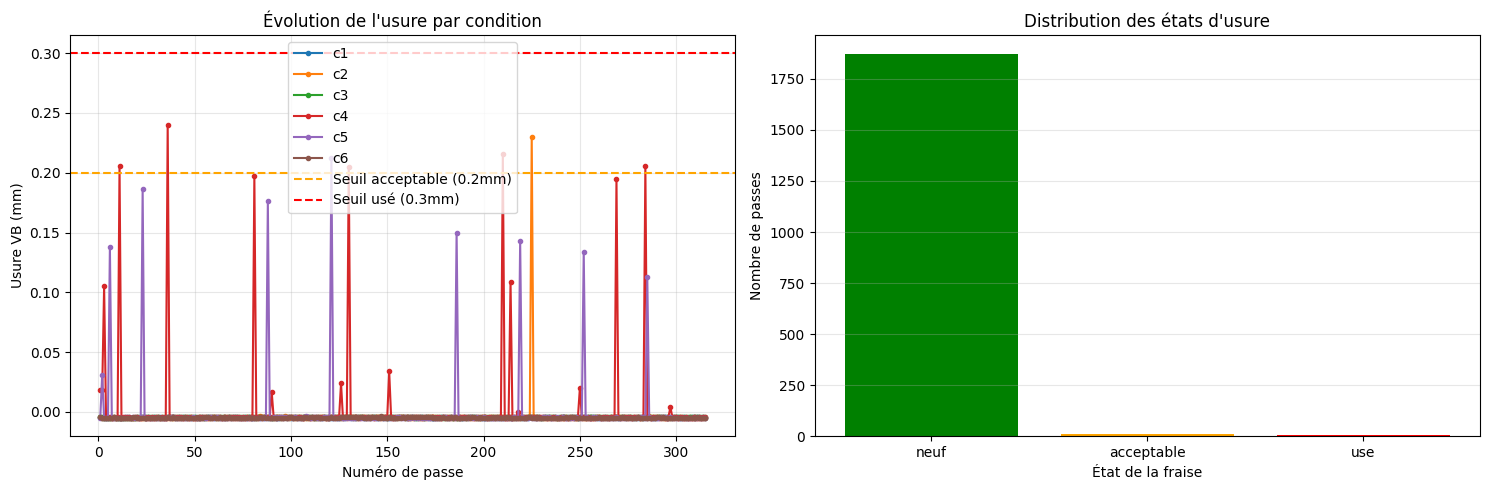

✅ Graphique sauvegardé


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Évolution du VB par passe et par condition ---
for cond, grp in df_features.groupby('condition'):
    grp_sorted = grp.sort_values('passe')
    axes[0].plot(grp_sorted['passe'], grp_sorted['ae'], marker='o', markersize=3, label=cond)

axes[0].axhline(0.2, color='orange', linestyle='--', label='Seuil acceptable (0.2mm)')
axes[0].axhline(0.3, color='red',    linestyle='--', label='Seuil usé (0.3mm)')
axes[0].set_xlabel('Numéro de passe')
axes[0].set_ylabel('Usure VB (mm)')
axes[0].set_title('Évolution de l\'usure par condition')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Distribution des états ---
counts = df_features['etat'].value_counts()
colors = ['green', 'orange', 'red', 'darkred']
axes[1].bar(counts.index, counts.values, 
            color=[c for c in colors[:len(counts)]])
axes[1].set_xlabel('État de la fraise')
axes[1].set_ylabel('Nombre de passes')
axes[1].set_title('Distribution des états d\'usure')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('usure_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

## 5. Corrélation features / usure

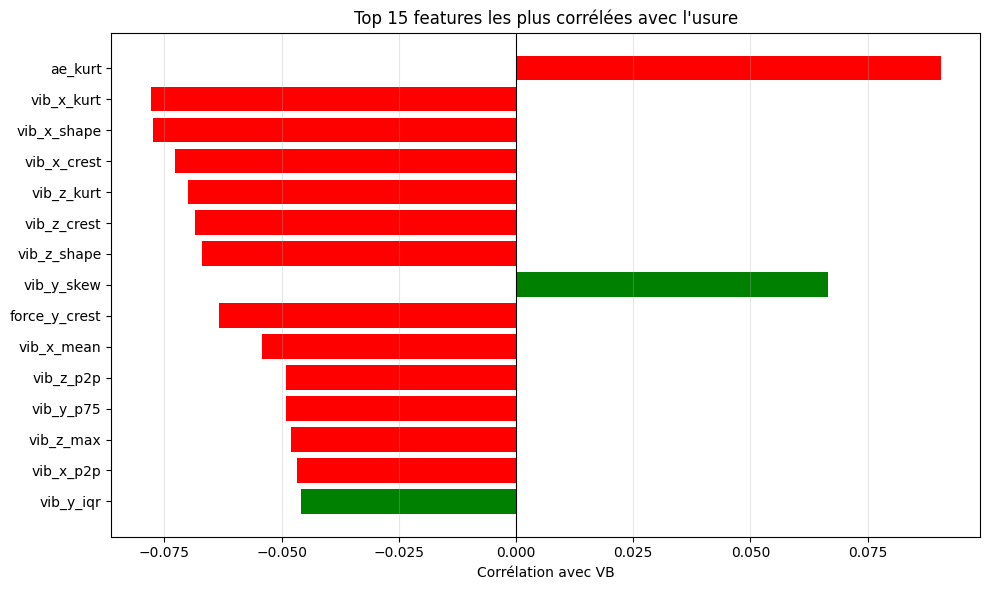


Top 5 features :
ae_kurt        0.090522
vib_x_kurt     0.077870
vib_x_shape    0.077432
vib_x_crest    0.072776
vib_z_kurt     0.069890
Name: ae, dtype: float64


In [6]:
feat_cols = [c for c in df_features.columns if c not in ['condition', 'passe', 'ae', 'etat']]

# Top 15 features les plus corrélées avec VB
corr_vb = df_features[feat_cols + ['ae']].corr()['ae'].drop('ae')
top15 = corr_vb.abs().nlargest(15)

plt.figure(figsize=(10, 6))
colors = ['green' if corr_vb[f] > 0 else 'red' for f in top15.index]
plt.barh(top15.index[::-1], corr_vb[top15.index[::-1]], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Corrélation avec VB')
plt.title('Top 15 features les plus corrélées avec l\'usure')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('correlation_vb.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features :')
print(top15.head())

## 6. Entraînement du modèle — Random Forest
**Stratégie : Leave-One-Condition-Out**  
Entraîner sur 2 conditions, tester sur la 3ème → évaluation réaliste.

In [7]:
feat_cols = [c for c in df_features.columns if c not in ['condition', 'passe', 'ae', 'etat']]

X = df_features[feat_cols].values
y = df_features['ae'].values
groups = df_features['condition'].values

# Leave-One-Condition-Out Cross Validation
logo = LeaveOneGroupOut()
model = RandomForestRegressor(n_estimators=100, random_state=42)

maes, rmses, r2s = [], [], []
results_detail = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    test_cond = np.unique(groups[test_idx])[0]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    maes.append(mae)
    rmses.append(rmse)
    r2s.append(r2)
    results_detail.append({'condition_test': test_cond, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    
    print(f'  Test sur {test_cond} → MAE={mae:.4f}mm | RMSE={rmse:.4f}mm | R²={r2:.3f}')

print(f'\n📊 Moyenne : MAE={np.mean(maes):.4f}mm | RMSE={np.mean(rmses):.4f}mm | R²={np.mean(r2s):.3f}')

  Test sur c1 → MAE=0.0085mm | RMSE=0.0276mm | R²=-3232.041
  Test sur c2 → MAE=0.0218mm | RMSE=0.0516mm | R²=-14.260
  Test sur c3 → MAE=0.0035mm | RMSE=0.0089mm | R²=-748.901
  Test sur c4 → MAE=0.0069mm | RMSE=0.0323mm | R²=0.030
  Test sur c5 → MAE=0.0068mm | RMSE=0.0262mm | R²=-0.028
  Test sur c6 → MAE=0.0131mm | RMSE=0.0363mm | R²=-6470.868

📊 Moyenne : MAE=0.0101mm | RMSE=0.0305mm | R²=-1744.345


## 7. Visualisation des prédictions vs réalité

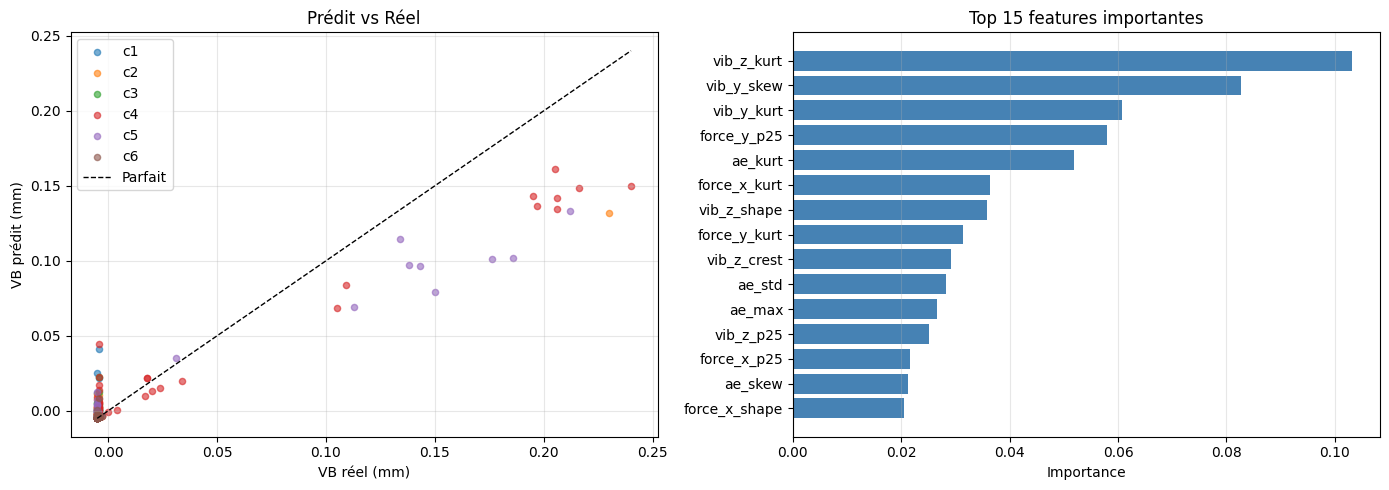

In [8]:
# Ré-entraîner sur toutes les données pour la visualisation
model.fit(X, y)
y_pred_all = model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter : prédit vs réel
conditions = df_features['condition'].values
for cond in np.unique(conditions):
    mask = conditions == cond
    axes[0].scatter(y[mask], y_pred_all[mask], label=cond, alpha=0.6, s=20)

lim = [y.min(), y.max()]
axes[0].plot(lim, lim, 'k--', linewidth=1, label='Parfait')
axes[0].set_xlabel('VB réel (mm)')
axes[0].set_ylabel('VB prédit (mm)')
axes[0].set_title('Prédit vs Réel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Importance des features (top 15)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_names = [feat_cols[i] for i in indices]

axes[1].barh(top_names[::-1], importances[indices[::-1]], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 features importantes')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('predictions_vs_reel.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export du DataFrame et du modèle

In [10]:
import pickle

# Sauvegarder le DataFrame de features
df_features.to_csv('phm2010_features.csv', index=False)
print('✅ Features sauvegardées → phm2010_features.csv')

# Sauvegarder le modèle
with open('rf_wear_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('✅ Modèle sauvegardé → rf_wear_model.pkl')

print(f'\n📋 Résumé final :')
print(f'   Passes totales : {len(df_features)}')
print(f'   Features : {len(feat_cols)}')
print(f'   Conditions : {list(df_features["condition"].unique())}')
print(f'   VB min/max : {df_features["ae"].min():.4f} / {df_features["ae"].max():.4f} mm')
pd.DataFrame(results_detail)

✅ Features sauvegardées → phm2010_features.csv
✅ Modèle sauvegardé → rf_wear_model.pkl

📋 Résumé final :
   Passes totales : 1890
   Features : 91
   Conditions : ['c1', 'c2', 'c3', 'c4', 'c5', 'c6']
   VB min/max : -0.0050 / 0.2400 mm


,condition_test,MAE,RMSE,R²
0,c1,0.008489,0.027567,-3232.040712
1,c2,0.021829,0.051608,-14.260222
2,c3,0.003470,0.008919,-748.901243
3,c4,0.006876,0.032278,0.030496
4,c5,0.006757,0.026246,-0.027719
5,c6,0.013062,0.036280,-6470.867796
